In [ ]:
# Mount google drive for persistence
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import os

# Base path to the project directory on Google Drive
BASE_PATH      = '/content/drive/MyDrive/javascript_malware'

# Path to the dataset directory
DATA_DIR       = f'{BASE_PATH}/data'

# Path to benign and obfuscated JavaScript samples
BENIGN_DIR     = f'{DATA_DIR}/JavascriptSamples'
OBFUSCATED_DIR = f'{DATA_DIR}/JavascriptSamplesObfuscated'

# Output directories for models, figures, and reports
OUTPUT_DIR     = f'{BASE_PATH}/output'
MODELS_DIR     = f'{OUTPUT_DIR}/models'
FIGURES_DIR    = f'{OUTPUT_DIR}/figures'
REPORTS_DIR    = f'{OUTPUT_DIR}/reports'

# Create output directories if they do not already exist
for folder in [MODELS_DIR, FIGURES_DIR, REPORTS_DIR]:
    os.makedirs(folder, exist_ok=True)
    print(f"Ready: {folder}")

Ready: /content/drive/MyDrive/javascript_malware/output/models
Ready: /content/drive/MyDrive/javascript_malware/output/figures
Ready: /content/drive/MyDrive/javascript_malware/output/reports


In [ ]:
import os
import pandas as pd

def load_javascript_files(directory, label):
    """
    Loads all JavaScript files from a directory and assigns a class label.

    Parameters:
        directory (str): Path to the folder containing JavaScript files.
        label (int): Class label to assign (0 = benign, 1 = obfuscated).

    Returns:
        list: A list of dictionaries containing filename, code, and label.
    """
    samples = []

    for fname in os.listdir(directory):
        if fname.endswith('.js'):
            fpath = os.path.join(directory, fname)
            try:
                code = open(fpath, 'r', encoding='utf-8', errors='ignore').read()
                samples.append({
                    'filename' : fname,
                    'code'     : code,
                    'label'    : label
                })
            except Exception as e:
                print(f"Skipped {fname}: {e}")

    return samples


def load_dataset(benign_dir, obfuscated_dir):
    """
    Loads benign and obfuscated JavaScript files into a single DataFrame.

    Parameters:
        benign_dir (str)    : Path to the folder containing benign JavaScript files.
        obfuscated_dir (str): Path to the folder containing obfuscated JavaScript files.

    Returns:
        pd.DataFrame: A DataFrame with columns filename, code, and label.
    """
    samples = []
    samples += load_javascript_files(benign_dir,     label=0)
    samples += load_javascript_files(obfuscated_dir, label=1)
    return pd.DataFrame(samples)


# Load the dataset from the specified directories
df = load_dataset(BENIGN_DIR, OBFUSCATED_DIR)

# Display a summary of the loaded dataset
print("Dataset Summary")
print("=" * 40)
print(f"Total files loaded  : {len(df)}")
print(f"Benign files    (0) : {len(df[df['label'] == 0])}")
print(f"Obfuscated files(1) : {len(df[df['label'] == 1])}")
print(f"Missing values      : {df.isnull().sum().sum()}")
print("=" * 40)
print(df.head())

Dataset Summary
Total files loaded  : 3375
Benign files    (0) : 1858
Obfuscated files(1) : 1517
Missing values      : 0
        filename                                               code  label
0      ngInit.js  'use strict';\n\n/**\n * @ngdoc directive\n * ...      0
1  ngInitSpec.js  'use strict';\n\ndescribe('ngInit', function()...      0
2  ng-jq.spec.js  'use strict';\n\ndescribe('Customizing the jqL...      0
3   ngKeySpec.js  'use strict';\n\ndescribe('ngKeyup and ngKeydo...      0
4      ngList.js  'use strict';\n\n\n/**\n * @ngdoc directive\n ...      0


Statistical Summary by Class
      file_size                                                              \
          count     mean       std  min      25%     50%      75%       max   
label                                                                         
0        1858.0  6033.03  30570.57  6.0   755.25  1527.5  2970.25  625499.0   
1        1517.0  5021.32  17308.74  0.0  1621.00  2891.0  3353.00  450003.0   

      entropy        ... num_lines          avg_line_len                     \
        count  mean  ...       75%      max        count     mean       std   
label                ...                                                      
0      1858.0  4.86  ...     101.0  19571.0       1858.0    67.38    721.11   
1      1517.0  5.28  ...       1.0   1357.0       1517.0  4054.71  16369.33   

                                                
       min     25%      50%      75%       max  
label                                           
0      3.0   23.77    27.49    3

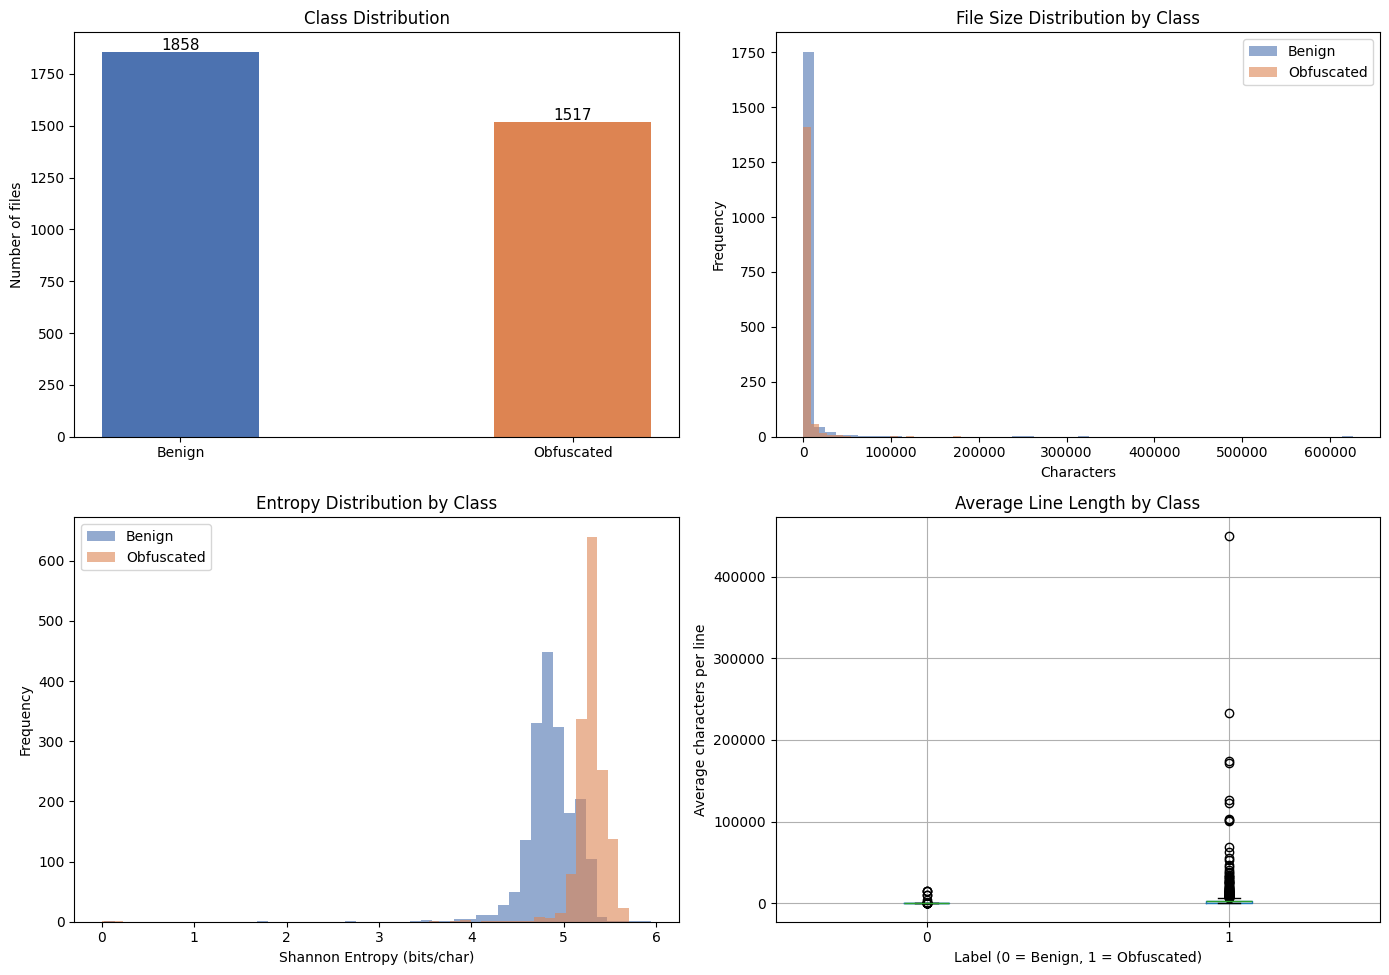

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Helper function to calculate Shannon entropy of a string
def calculate_entropy(text):
    if not text:
        return 0
    freq = {}
    for c in text:
        freq[c] = freq.get(c, 0) + 1
    return -sum((v / len(text)) * math.log2(v / len(text)) for v in freq.values())

# Add basic statistical columns to the DataFrame
df['file_size']    = df['code'].str.len()
df['entropy']      = df['code'].apply(calculate_entropy)
df['num_lines']    = df['code'].apply(lambda x: x.count('\n') + 1)
df['avg_line_len'] = df['file_size'] / df['num_lines']

# Print statistical summary grouped by class label
print("Statistical Summary by Class")
print("=" * 60)
print(df.groupby('label')[['file_size', 'entropy', 'num_lines', 'avg_line_len']].describe().round(2))
print("=" * 60)

# Define class labels and colors for plots
labels      = ['Benign', 'Obfuscated']
colors      = ['#4C72B0', '#DD8452']
label_names = {0: 'Benign', 1: 'Obfuscated'}

# Initialize the figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis — JavaScript Dataset', fontsize=14)

# Plot 1: Class distribution bar chart
class_counts = df['label'].value_counts().sort_index()
axes[0, 0].bar(labels, class_counts.values, color=colors, width=0.4)
axes[0, 0].set_title('Class Distribution')
axes[0, 0].set_ylabel('Number of files')
for i, v in enumerate(class_counts.values):
    axes[0, 0].text(i, v + 10, str(v), ha='center', fontsize=11)

# Plot 2: File size distribution by class
for label, color in zip([0, 1], colors):
    subset = df[df['label'] == label]['file_size']
    axes[0, 1].hist(subset, bins=50, alpha=0.6, color=color, label=label_names[label])
axes[0, 1].set_title('File Size Distribution by Class')
axes[0, 1].set_xlabel('Characters')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Plot 3: Entropy distribution by class
for label, color in zip([0, 1], colors):
    subset = df[df['label'] == label]['entropy']
    axes[1, 0].hist(subset, bins=50, alpha=0.6, color=color, label=label_names[label])
axes[1, 0].set_title('Entropy Distribution by Class')
axes[1, 0].set_xlabel('Shannon Entropy (bits/char)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Plot 4: Average line length boxplot by class
bp = df.boxplot(
    column='avg_line_len',
    by='label',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Average Line Length by Class')
axes[1, 1].set_xlabel('Label (0 = Benign, 1 = Obfuscated)')
axes[1, 1].set_ylabel('Average characters per line')
plt.suptitle('')

# Adjust layout and save figure to output directory
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/eda_overview.png', dpi=150, bbox_inches='tight')
print(f"Figure saved to: {FIGURES_DIR}/eda_overview.png")
plt.show()

In [ ]:
import re
import math
import pandas as pd

def calculate_entropy(text):
    """
    Calculates the Shannon entropy of a given string.

    Parameters:
        text (str): Input string to calculate entropy for.

    Returns:
        float: Shannon entropy value in bits per character.
    """
    if not text:
        return 0
    freq = {}
    for c in text:
        freq[c] = freq.get(c, 0) + 1
    return -sum((v / len(text)) * math.log2(v / len(text)) for v in freq.values())


def extract_features(code):
    """
    Extracts a set of statistical and structural features from a JavaScript code string.

    Parameters:
        code (str): Raw JavaScript source code.

    Returns:
        dict: A dictionary of feature names and their computed values.
    """
    features = {}

    # Basic file size features
    features['file_size']         = len(code)
    features['num_lines']         = code.count('\n') + 1
    features['avg_line_len']      = len(code) / max(code.count('\n') + 1, 1)
    features['max_line_len']      = max((len(l) for l in code.split('\n')), default=0)

    # Entropy features
    features['entropy']           = calculate_entropy(code)

    # Character ratio features
    total_chars                   = max(len(code), 1)
    features['special_char_ratio']= len(re.findall(r'[^a-zA-Z0-9\s]', code)) / total_chars
    features['digit_ratio']       = len(re.findall(r'[0-9]', code))             / total_chars
    features['uppercase_ratio']   = len(re.findall(r'[A-Z]', code))             / total_chars
    features['space_ratio']       = len(re.findall(r'\s', code))                / total_chars

    # Obfuscation indicator features
    features['hex_escape_count']  = len(re.findall(r'\\x[0-9a-fA-F]{2}', code))
    features['unicode_escape_count'] = len(re.findall(r'\\u[0-9a-fA-F]{4}', code))
    features['base64_count']      = len(re.findall(r'[A-Za-z0-9+/]{40,}={0,2}', code))
    features['long_string_count'] = len(re.findall(r'["\'][^"\']{200,}["\']', code))

    # Dynamic execution features
    features['eval_count']        = len(re.findall(r'\beval\s*\(', code))
    features['unescape_count']    = len(re.findall(r'\bunescape\s*\(', code))
    features['atob_count']        = len(re.findall(r'\batob\s*\(', code))
    features['function_constructor'] = len(re.findall(r'Function\s*\(', code))
    features['settimeout_count']  = len(re.findall(r'\bsetTimeout\s*\(', code))
    features['setinterval_count'] = len(re.findall(r'\bsetInterval\s*\(', code))
    features['document_write']    = len(re.findall(r'document\.write\s*\(', code))

    # String and identifier features
    identifiers                   = re.findall(r'\b[a-zA-Z_$][a-zA-Z0-9_$]*\b', code)
    features['num_identifiers']   = len(identifiers)
    features['avg_identifier_len']= sum(len(i) for i in identifiers) / max(len(identifiers), 1)

    identifier_entropies          = [calculate_entropy(i) for i in identifiers if len(i) > 2]
    features['avg_identifier_entropy'] = sum(identifier_entropies) / max(len(identifier_entropies), 1)

    # String array pattern features common in obfuscated code
    features['array_access_count']= len(re.findall(r'\w+\[0x[0-9a-fA-F]+\]', code))
    features['hex_array_index']   = len(re.findall(r'\[0x[0-9a-fA-F]+\]', code))

    # Structural features
    features['num_functions']     = len(re.findall(r'\bfunction\b', code))
    features['num_var_decl']      = len(re.findall(r'\bvar\b', code))
    features['num_semicolons']    = code.count(';')
    features['num_commas']        = code.count(',')
    features['bracket_ratio']     = (code.count('(') + code.count(')')) / total_chars
    features['square_bracket_ratio'] = (code.count('[') + code.count(']')) / total_chars

    return features


# Apply feature extraction to all files in the dataset
print("Extracting features from all files...")
feature_dicts = df['code'].apply(extract_features)
X             = pd.DataFrame(feature_dicts.tolist())
y             = df['label'].values

# Print feature extraction summary
print("Feature Extraction Complete")
print("=" * 40)
print(f"Total samples   : {X.shape[0]}")
print(f"Total features  : {X.shape[1]}")
print(f"Feature names   : {list(X.columns)}")
print("=" * 40)

# Check for any missing values in the feature matrix
missing = X.isnull().sum()
if missing.sum() == 0:
    print("No missing values found in feature matrix.")
else:
    print("Missing values detected:")
    print(missing[missing > 0])

# Save feature matrix to output directory for reuse
X.to_csv(f'{REPORTS_DIR}/feature_matrix.csv', index=False)
print(f"Feature matrix saved to: {REPORTS_DIR}/feature_matrix.csv")

Extracting features from all files...
Feature Extraction Complete
Total samples   : 3375
Total features  : 31
Feature names   : ['file_size', 'num_lines', 'avg_line_len', 'max_line_len', 'entropy', 'special_char_ratio', 'digit_ratio', 'uppercase_ratio', 'space_ratio', 'hex_escape_count', 'unicode_escape_count', 'base64_count', 'long_string_count', 'eval_count', 'unescape_count', 'atob_count', 'function_constructor', 'settimeout_count', 'setinterval_count', 'document_write', 'num_identifiers', 'avg_identifier_len', 'avg_identifier_entropy', 'array_access_count', 'hex_array_index', 'num_functions', 'num_var_decl', 'num_semicolons', 'num_commas', 'bracket_ratio', 'square_bracket_ratio']
No missing values found in feature matrix.
Feature matrix saved to: /content/drive/MyDrive/javascript_malware/output/reports/feature_matrix.csv


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define feature matrix and target labels
X = pd.read_csv(f'{REPORTS_DIR}/feature_matrix.csv')
y = df['label'].values

# Split dataset into training and testing subsets using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features for models sensitive to feature magnitude
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for consistency
X_train_sc  = pd.DataFrame(X_train_sc, columns=X.columns)
X_test_sc   = pd.DataFrame(X_test_sc,  columns=X.columns)

# Print split summary
print("Train/Test Split Summary")
print("=" * 40)
print(f"Total samples       : {len(X)}")
print(f"Training samples    : {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing samples     : {len(X_test)}  ({len(X_test)/len(X)*100:.1f}%)")
print("=" * 40)
print(f"Training class distribution:")
print(f"  Benign (0)        : {sum(y_train == 0)}")
print(f"  Obfuscated (1)    : {sum(y_train == 1)}")
print(f"Testing class distribution:")
print(f"  Benign (0)        : {sum(y_test == 0)}")
print(f"  Obfuscated (1)    : {sum(y_test == 1)}")
print("=" * 40)

# Save scaler for later use
import pickle
with open(f'{MODELS_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to: {MODELS_DIR}/scaler.pkl")

Train/Test Split Summary
Total samples       : 3375
Training samples    : 2700 (80.0%)
Testing samples     : 675  (20.0%)
Training class distribution:
  Benign (0)        : 1486
  Obfuscated (1)    : 1214
Testing class distribution:
  Benign (0)        : 372
  Obfuscated (1)    : 303
Scaler saved to: /content/drive/MyDrive/javascript_malware/output/models/scaler.pkl


In [ ]:
import pickle
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Define the three models to train and evaluate
models = {
    'Random Forest': {
        'model'  : RandomForestClassifier(
                        n_estimators=200,
                        max_depth=None,
                        min_samples_split=2,
                        random_state=42,
                        n_jobs=-1
                    ),
        'scaled' : False
    },
    'Gradient Boosting': {
        'model'  : GradientBoostingClassifier(
                        n_estimators=200,
                        learning_rate=0.1,
                        max_depth=3,
                        random_state=42
                    ),
        'scaled' : False
    },
    'Logistic Regression': {
        'model'  : LogisticRegression(
                        C=1.0,
                        max_iter=1000,
                        random_state=42
                    ),
        'scaled' : True
    }
}

# Train each model and store results
results = {}

for name, config in models.items():

    print(f"Training {name}...")

    # Select scaled or unscaled data depending on the model
    X_tr = X_train_sc if config['scaled'] else X_train
    X_te = X_test_sc  if config['scaled'] else X_test

    # Train the model
    config['model'].fit(X_tr, y_train)

    # Generate predictions and probability scores
    y_pred = config['model'].predict(X_te)
    y_prob = config['model'].predict_proba(X_te)[:, 1]

    # Calculate evaluation metrics
    results[name] = {
        'accuracy'  : accuracy_score(y_test, y_pred),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        'conf_matrix': confusion_matrix(y_test, y_pred),
        'report'    : classification_report(y_test, y_pred, target_names=['Benign', 'Obfuscated']),
        'y_pred'    : y_pred,
        'y_prob'    : y_prob
    }

    # Save trained model to output directory
    model_path = f'{MODELS_DIR}/{name.lower().replace(" ", "_")}.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(config['model'], f)

    print(f"  Accuracy : {results[name]['accuracy']:.4f}")
    print(f"  ROC AUC  : {results[name]['roc_auc']:.4f}")
    print(f"  Saved to : {model_path}")
    print()

# Print full classification report for each model
print("=" * 60)
print("Full Classification Reports")
print("=" * 60)
for name, result in results.items():
    print(f"\n{name}")
    print("-" * 40)
    print(result['report'])

Training Random Forest...
  Accuracy : 0.9941
  ROC AUC  : 0.9992
  Saved to : /content/drive/MyDrive/javascript_malware/output/models/random_forest.pkl

Training Gradient Boosting...
  Accuracy : 0.9926
  ROC AUC  : 0.9990
  Saved to : /content/drive/MyDrive/javascript_malware/output/models/gradient_boosting.pkl

Training Logistic Regression...
  Accuracy : 0.9822
  ROC AUC  : 0.9871
  Saved to : /content/drive/MyDrive/javascript_malware/output/models/logistic_regression.pkl

Full Classification Reports

Random Forest
----------------------------------------
              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99       372
  Obfuscated       1.00      0.99      0.99       303

    accuracy                           0.99       675
   macro avg       0.99      0.99      0.99       675
weighted avg       0.99      0.99      0.99       675


Gradient Boosting
----------------------------------------
              precision    recall  f1-score   s

Saved: /content/drive/MyDrive/javascript_malware/output/figures/confusion_matrices.png


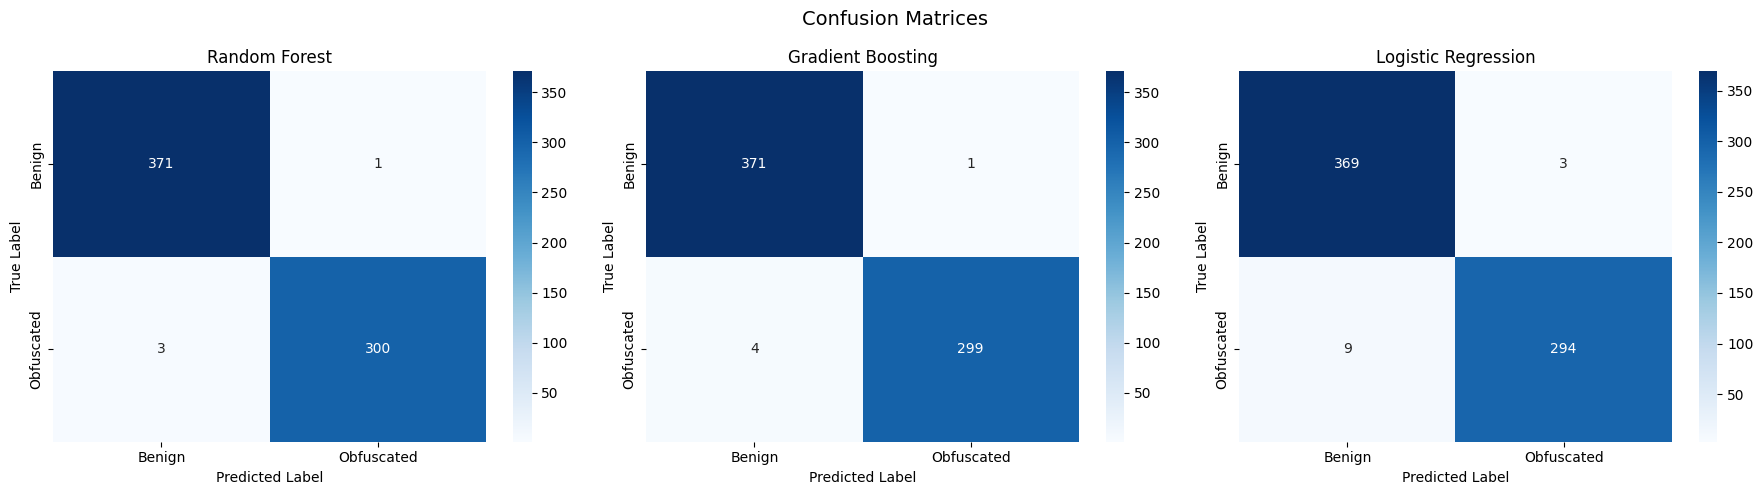

Saved: /content/drive/MyDrive/javascript_malware/output/figures/roc_curves.png


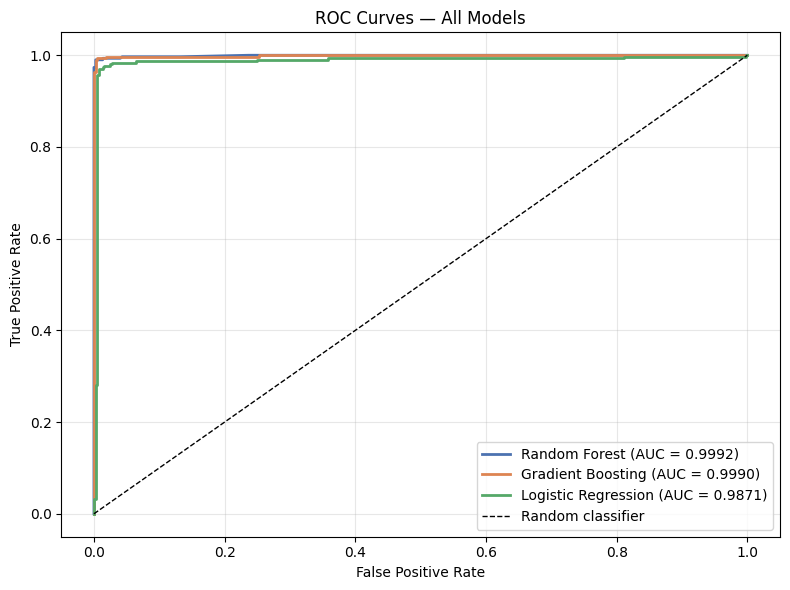

Saved: /content/drive/MyDrive/javascript_malware/output/figures/model_comparison.png


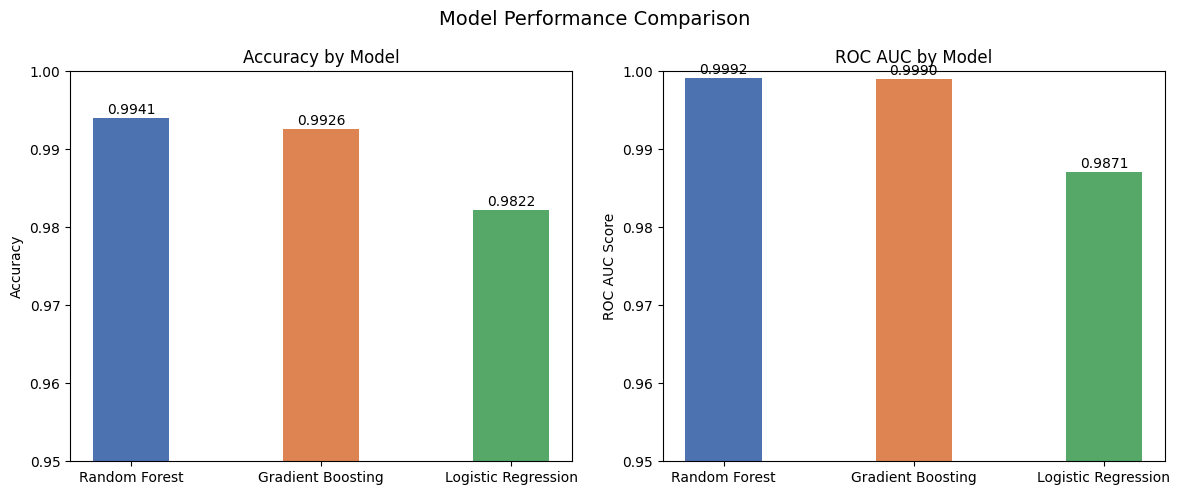

Saved: /content/drive/MyDrive/javascript_malware/output/figures/feature_importance.png


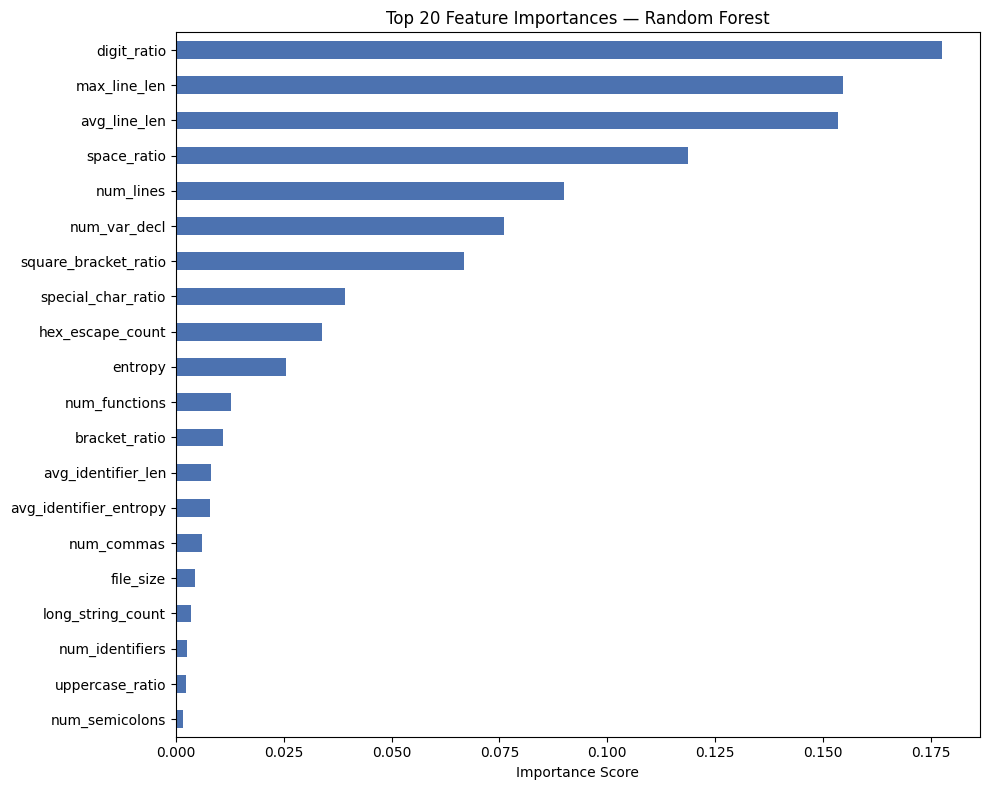

Final Model Performance Summary
Model                       Accuracy    ROC AUC
--------------------------------------------------
Random Forest                 0.9941     0.9992
Gradient Boosting             0.9926     0.9990
Logistic Regression           0.9822     0.9871


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve

# Define class names for plot labels
class_names = ['Benign', 'Obfuscated']
model_names = list(results.keys())
colors      = ['#4C72B0', '#DD8452', '#55A868']

# Plot 1: Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=14)

for ax, (name, result) in zip(axes, results.items()):
    cm = result['conf_matrix']
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/confusion_matrices.png', dpi=150, bbox_inches='tight')
print(f"Saved: {FIGURES_DIR}/confusion_matrices.png")
plt.show()

# Plot 2: ROC curves for all three models overlaid
fig, ax = plt.subplots(figsize=(8, 6))

for (name, result), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    auc          = result['roc_auc']
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_title('ROC Curves — All Models')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/roc_curves.png', dpi=150, bbox_inches='tight')
print(f"Saved: {FIGURES_DIR}/roc_curves.png")
plt.show()

# Plot 3: Model accuracy and ROC AUC comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Performance Comparison', fontsize=14)

accuracy_scores = [results[n]['accuracy'] for n in model_names]
roc_auc_scores  = [results[n]['roc_auc']  for n in model_names]

axes[0].bar(model_names, accuracy_scores, color=colors, width=0.4)
axes[0].set_title('Accuracy by Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0.95, 1.0])
for i, v in enumerate(accuracy_scores):
    axes[0].text(i, v + 0.0005, f'{v:.4f}', ha='center', fontsize=10)

axes[1].bar(model_names, roc_auc_scores, color=colors, width=0.4)
axes[1].set_title('ROC AUC by Model')
axes[1].set_ylabel('ROC AUC Score')
axes[1].set_ylim([0.95, 1.0])
for i, v in enumerate(roc_auc_scores):
    axes[1].text(i, v + 0.0005, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/model_comparison.png', dpi=150, bbox_inches='tight')
print(f"Saved: {FIGURES_DIR}/model_comparison.png")
plt.show()

# Plot 4: Feature importance from Random Forest
fig, ax = plt.subplots(figsize=(10, 8))

rf_model          = models['Random Forest']['model']
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

feature_importances.tail(20).plot(
    kind='barh',
    ax=ax,
    color='#4C72B0'
)
ax.set_title('Top 20 Feature Importances — Random Forest')
ax.set_xlabel('Importance Score')

plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/feature_importance.png', dpi=150, bbox_inches='tight')
print(f"Saved: {FIGURES_DIR}/feature_importance.png")
plt.show()

# Print final summary table
print("Final Model Performance Summary")
print("=" * 50)
print(f"{'Model':<25} {'Accuracy':>10} {'ROC AUC':>10}")
print("-" * 50)
for name, result in results.items():
    print(f"{name:<25} {result['accuracy']:>10.4f} {result['roc_auc']:>10.4f}")
print("=" * 50)